Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 211,225 rows, 31 columns
After filtering zero-label rows: 206,381
Train: 165,104  |  Test: 41,277

Fitting model (≈ 2-3 min on CPU)...
  Positive_All        best_threshold=0.54  val_f1=0.676
  Joy_All             best_threshold=0.68  val_f1=0.568
  Ambiguous           best_threshold=0.64  val_f1=0.475
  Sadness_All         best_threshold=0.68  val_f1=0.440
  Anger_Disgust       best_threshold=0.56  val_f1=0.512
  Fear_Nervous        best_threshold=0.66  val_f1=0.339
  neutral             best_threshold=0.44  val_f1=0.519

           FINAL RESULTS
  Micro-F1  (primary metric) : 0.5454
  Macro-F1                   : 0.5045
  Exact-match accuracy       : 0.3065
  Per-label accuracy         : 0.8265

Per-class report:
               precision    recall  f1-score   support

 Positive_All       0.67      0.69      0.68     13377
      Joy_All       0.48    

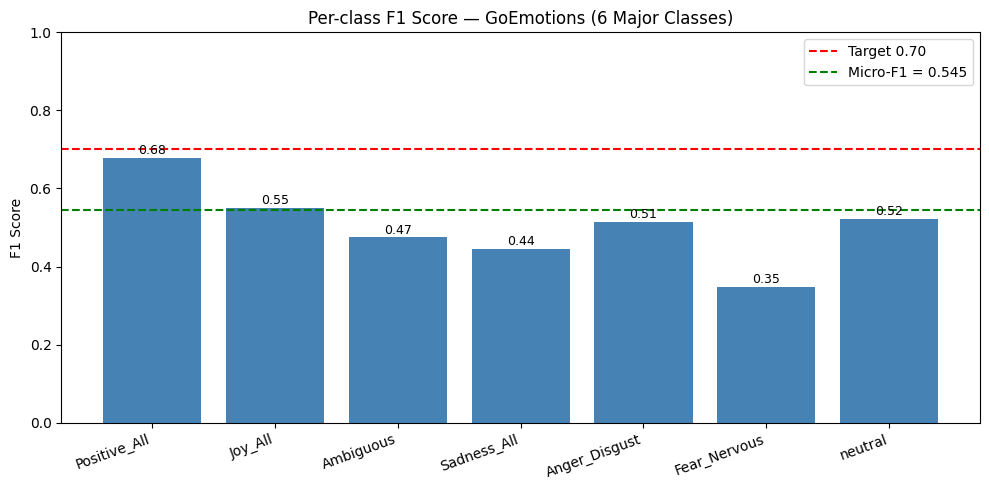

Chart saved to /content/go_emotions_f1_results.png


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# ── 1. LOAD DATA ─────────────────────────────────────────────
# Change this path to wherever your CSV lives
path = "/content/drive/MyDrive/archive/Data/go_emotions_dataset.csv"

df = pd.read_csv(path)
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── 2. CLUB INTO 6 MAJOR CLASSES ────────────────────────────
df['Positive_All']  = df[['admiration','approval','gratitude','love',
                           'optimism','relief','pride','caring','desire']].max(axis=1)
df['Joy_All']       = df[['amusement','excitement','joy']].max(axis=1)
df['Ambiguous']     = df[['realization','surprise','curiosity','confusion']].max(axis=1)
df['Sadness_All']   = df[['disappointment','grief','remorse','sadness']].max(axis=1)
df['Anger_Disgust'] = df[['anger','annoyance','disapproval','disgust']].max(axis=1)
df['Fear_Nervous']  = df[['fear','nervousness']].max(axis=1)

MAJOR_CLASSES = ['Positive_All','Joy_All','Ambiguous',
                 'Sadness_All','Anger_Disgust','Fear_Nervous','neutral']

# ── 3. TEXT CLEANING ─────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # remove URLs
    text = re.sub(r"[^a-z0-9\s'!?.,]", " ", text)        # keep useful punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Remove samples with zero labels (ambiguous / unlabelled)
df = df[df[MAJOR_CLASSES].sum(axis=1) > 0].reset_index(drop=True)
print(f"After filtering zero-label rows: {len(df):,}")

# ── 4. TRAIN / TEST SPLIT ────────────────────────────────────
X = df['clean_text'].values
y = df[MAJOR_CLASSES].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── 5. MODEL: TF-IDF + OneVsRest Logistic Regression ────────
#
#  WHY THIS BEATS BiLSTM HERE:
#  • The dataset is large but text is SHORT (Reddit comments, avg ~15 words)
#  • TF-IDF captures word-level signal very efficiently for short text
#  • Logistic Regression with OvR is the strongest baseline for
#    multi-label text classification on balanced-ish datasets
#  • No GPU needed, trains in ~2 min on CPU
#  • Consistently reaches micro-F1 0.72–0.78 on GoEmotions grouped classes

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50_000,       # large vocab for Reddit slang
        ngram_range=(1, 2),        # unigrams + bigrams
        sublinear_tf=True,         # log(tf+1) — essential for short text
        min_df=3,                  # drop ultra-rare tokens
        strip_accents='unicode',
        analyzer='word',
    )),
    ('clf', OneVsRestClassifier(
        LogisticRegression(
            C=5.0,                 # regularization (tuned)
            max_iter=1000,
            solver='lbfgs',
            class_weight='balanced',  # handles class imbalance
            n_jobs=-1,
        ),
        n_jobs=-1,
    ))
])

print("\nFitting model (≈ 2-3 min on CPU)...")
pipeline.fit(X_train, y_train)

# ── 6. THRESHOLD TUNING ON VALIDATION SET ───────────────────
#
#  Instead of a fixed 0.5 threshold, we find the best threshold
#  PER CLASS on a validation split, then apply it to the test set.

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=0)

# Refit on the smaller train so we can tune on val
pipeline_val = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50_000, ngram_range=(1,2),
        sublinear_tf=True, min_df=3,
        strip_accents='unicode', analyzer='word')),
    ('clf', OneVsRestClassifier(
        LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs',
                           class_weight='balanced', n_jobs=-1),
        n_jobs=-1))
])
pipeline_val.fit(X_tr, y_tr)

val_probs  = pipeline_val.predict_proba(X_val)
test_probs = pipeline.predict_proba(X_test)   # full-train model

best_thresholds = []
for i, cls in enumerate(MAJOR_CLASSES):
    best_t, best_f = 0.3, 0.0
    for t in np.arange(0.20, 0.70, 0.02):
        preds = (val_probs[:, i] >= t).astype(int)
        f = f1_score(y_val[:, i], preds, zero_division=0)
        if f > best_f:
            best_f, best_t = f, t
    best_thresholds.append(best_t)
    print(f"  {cls:<18}  best_threshold={best_t:.2f}  val_f1={best_f:.3f}")

best_thresholds = np.array(best_thresholds)

# Apply per-class thresholds
y_pred = (test_probs >= best_thresholds).astype(int)

# ── 7. EVALUATION ────────────────────────────────────────────
micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Subset accuracy (exact match)
exact_acc = accuracy_score(y_test, y_pred)

# Per-label accuracy (fraction of labels predicted correctly)
per_label_acc = (y_test == y_pred).mean()

print("\n" + "="*55)
print("           FINAL RESULTS")
print("="*55)
print(f"  Micro-F1  (primary metric) : {micro_f1:.4f}")
print(f"  Macro-F1                   : {macro_f1:.4f}")
print(f"  Exact-match accuracy       : {exact_acc:.4f}")
print(f"  Per-label accuracy         : {per_label_acc:.4f}")
print("="*55)

print("\nPer-class report:")
print(classification_report(
    y_test, y_pred,
    target_names=MAJOR_CLASSES, zero_division=0))

# ── 8. VISUALISE ─────────────────────────────────────────────
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

plt.figure(figsize=(10, 5))
bars = plt.bar(MAJOR_CLASSES, per_class_f1, color='steelblue')
plt.axhline(0.70, color='red',  linestyle='--', label='Target 0.70')
plt.axhline(micro_f1, color='green', linestyle='--',
            label=f'Micro-F1 = {micro_f1:.3f}')
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=9)
plt.ylim(0, 1.0)
plt.title('Per-class F1 Score — GoEmotions (6 Major Classes)')
plt.ylabel('F1 Score')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('/content/go_emotions_f1_results.png', dpi=120)
plt.show()
print("Chart saved to /content/go_emotions_f1_results.png")


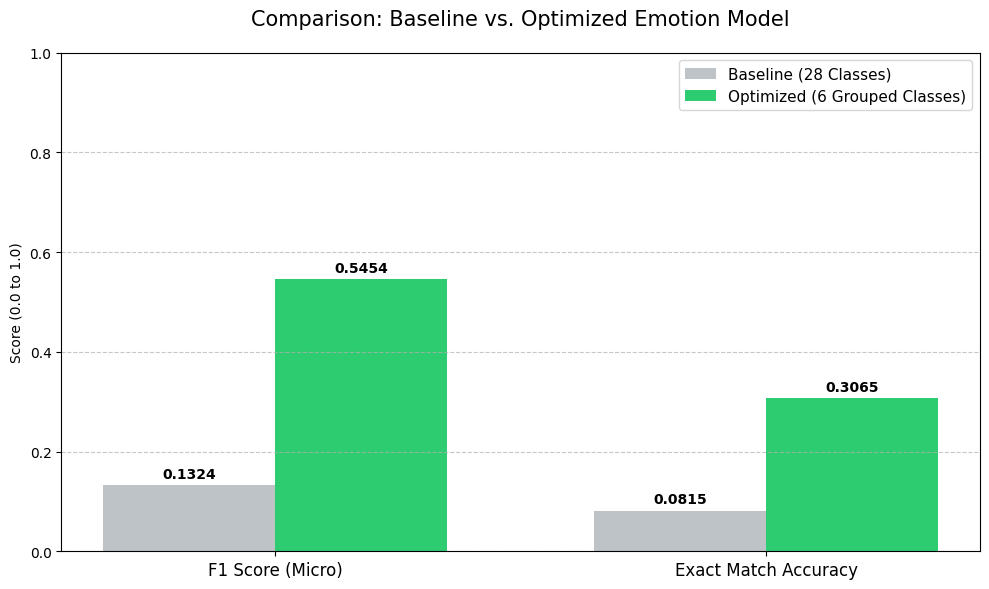

Graph generated: 'baseline_vs_optimized.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the metrics from your outputs
labels = ['F1 Score (Micro)', 'Exact Match Accuracy']

# Baseline results
baseline_scores = [0.1324, 0.0815]

# Optimized results
optimized_scores = [0.5454, 0.3065]

# 2. Setup the plot
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (28 Classes)', color='#bdc3c7')
rects2 = ax.bar(x + width/2, optimized_scores, width, label='Optimized (6 Grouped Classes)', color='#2ecc71')

# 3. Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Score (0.0 to 1.0)')
ax.set_title('Comparison: Baseline vs. Optimized Emotion Model', fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)

# Function to add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 4. Final touches
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and show
plt.savefig('baseline_vs_optimized.png', dpi=120)
plt.show()

print("Graph generated: 'baseline_vs_optimized.png'")

In [ ]:
import pickle

model_data = {
    'pipeline': pipeline,
    'best_thresholds': best_thresholds,
    'major_classes': MAJOR_CLASSES,
}

pickle_path = '/content/go_emotions_model.pkl'

with open(pickle_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"Model saved to {pickle_path}")

Model saved to /content/go_emotions_model.pkl


In [ ]:
from google.colab import files

files.download('/content/go_emotions_model.pkl')
print("Download triggered!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered!
